# 公共账户 / 券商 / 策略 / 引擎验证

本实验读取 q2 已有的三只 ETF 缓存。策略只能看到决策日以前的数据，订单在决策日开盘成交，账户在收盘后保存当日快照。

In [1]:
# 实验参数只在此处修改
DATA_START = '2023-03-05'
DATA_END = '2026-03-05'
INITIAL_CASH = 1_000_000.0
CANDIDATES = ['518880.SS', '513100.SS', '510300.SS']

In [2]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display

project_root = next(
    (p for p in (Path.cwd(), *Path.cwd().parents)
     if (p / 'xquant_learning').is_dir() and (p / 'pyproject.toml').is_file()),
    None,
)
if project_root is None:
    raise RuntimeError('找不到 xquant-learning-sxl 项目根目录')
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from xquant_learning.backtest import (
    Account, DataFrameDataSource, Engine, Order, SimBroker, Strategy,
)

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
print(f'公共模块：{project_root / "xquant_learning"}')

公共模块：D:\proj\xquant\xquant-learning-sxl\xquant_learning


In [3]:
cache_dir = project_root / 'q2' / 'data'
frames = {}
for symbol in CANDIDATES:
    cache_file = cache_dir / f"{symbol.replace('.', '_')}_2023-03-05_2026-03-05_auto_adjust.csv"
    if not cache_file.is_file():
        raise FileNotFoundError(f'缺少 q2 本地缓存：{cache_file}')
    frames[symbol] = pd.read_csv(
        cache_file, index_col='Date', parse_dates=['Date']
    )

data_source = DataFrameDataSource(frames)
broker = SimBroker(
    data_source=data_source,
    start=DATA_START,
    end=DATA_END,
    candidates=CANDIDATES,
)
print(f'共同完整交易日：{len(broker.trading_dates)} 天')
print(f'实际区间：{broker.trading_dates.min().date()} 至 {broker.trading_dates.max().date()}')
display(broker.close_prices.head())

共同完整交易日：725 天
实际区间：2023-03-06 至 2026-03-05


,518880.SS,513100.SS,510300.SS
Date,,,
2023-03-06,4.071,0.871,3.825208
2023-03-07,4.076,0.872,3.772015
2023-03-08,4.033,0.864,3.757084
2023-03-09,4.033,0.868,3.747752
2023-03-10,4.061,0.848,3.696426


## 示例策略（只用于验证接口）

等待 20 个历史交易日后，按前一日收盘价估算股数，将资金近似等分并买入一次。具体策略仍由后续实验实现。

In [4]:
class EqualWeightOnceStrategy(Strategy):
    def __init__(self, symbols, warmup=20, cash_buffer=0.95):
        self.symbols = tuple(symbols)
        self.warmup = warmup
        self.cash_buffer = cash_buffer
        self.reset()

    def reset(self):
        self.has_submitted = False
        self.observations = []

    def generate_orders(self, account, market, date):
        last_seen = market.close.index.max() if not market.close.empty else None
        self.observations.append((date, last_seen))
        if self.has_submitted or len(market.close) < self.warmup:
            return []

        budget = account.cash * self.cash_buffer / len(self.symbols)
        orders = []
        for symbol in self.symbols:
            reference_price = float(market.close[symbol].iloc[-1])
            shares = int(budget // reference_price)
            if shares > 0:
                orders.append(Order(symbol, 'BUY', shares))
        self.has_submitted = True
        return orders


account = Account(initial_cash=INITIAL_CASH, symbols=CANDIDATES)
strategy = EqualWeightOnceStrategy(CANDIDATES)
engine = Engine(account=account, broker=broker, strategy=strategy)
history = engine.run()

In [5]:
assert isinstance(account.history, list)
assert len(account.history) == len(broker.trading_dates)
assert all(set(snapshot.positions) == set(CANDIDATES) for snapshot in account.history)
assert all(last_seen is None or last_seen < date
           for date, last_seen in strategy.observations)
assert all(result.status == 'FILLED' for result in broker.order_history)

print('PASS：策略未看到当日或未来价格')
print('PASS：账户每天保存现金、全部持仓、收盘价和总资产')
print(f'成交 {len(broker.trades)} 笔；拒单 {sum(r.status == "REJECTED" for r in broker.order_history)} 笔')
display(history.tail())

PASS：策略未看到当日或未来价格
PASS：账户每天保存现金、全部持仓、收盘价和总资产
成交 3 笔；拒单 0 笔


,cash,portfolio_value,position_518880.SS,position_513100.SS,position_510300.SS,close_518880.SS,close_513100.SS,close_510300.SS
Date,,,,,,,,
2026-02-27,46982.059178,1.885958e+06,73970,348751,83785,10.933,1.819,4.725
2026-03-02,46982.059178,1.917004e+06,73970,348751,83785,11.417,1.802,4.739
2026-03-03,46982.059178,1.894626e+06,73970,348751,83785,11.259,1.786,4.678
2026-03-04,46982.059178,1.859921e+06,73970,348751,83785,10.980,1.762,4.610
2026-03-05,46982.059178,1.875676e+06,73970,348751,83785,10.964,1.800,4.654


In [6]:
statistics = engine.statistics()
display(statistics.map(lambda value: f'{value:.2%}').to_frame('统计值'))
print(f'累计收益率：{engine.cumulative_return():.2%}')
print(f'年化波动率：{engine.annualized_volatility():.2%}')
print(f'最大回撤：{engine.max_drawdown():.2%}')

,统计值
cumulative_return,87.57%
annualized_volatility,12.53%
max_drawdown,9.34%


累计收益率：87.57%
年化波动率：12.53%
最大回撤：9.34%


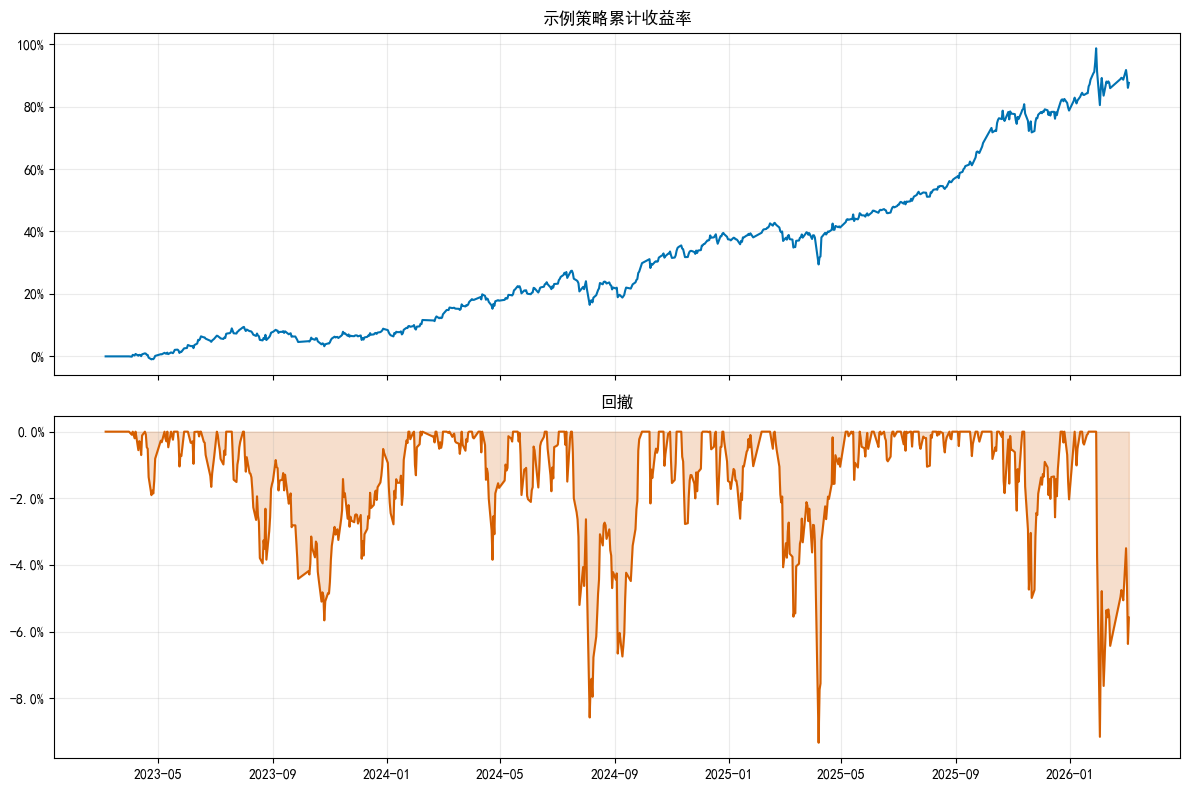

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
cumulative = history['portfolio_value'] / INITIAL_CASH - 1
axes[0].plot(history.index, cumulative, color='#0072B2')
axes[0].set_title('示例策略累计收益率')
axes[0].yaxis.set_major_formatter(PercentFormatter(1))
axes[1].plot(history.index, engine.drawdown(), color='#D55E00')
axes[1].fill_between(history.index, engine.drawdown(), 0, alpha=0.2, color='#D55E00')
axes[1].set_title('回撤')
axes[1].yaxis.set_major_formatter(PercentFormatter(1))
for ax in axes:
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()